# **MAYAN CULTURE SIMULATION**

Present data structure, having in mind the team(i) will be all of our teams that will be competing

Parameters needed:
* player (1: skilled master, 0: unskilled completely)
* team (chromosome): array of 7 floats, which will be the seven players between 0.0 and 1.0
* fitness function: team competitiveness, define it as the average of the 7 players skill levels

The idea is to obtain the final fitness of the whole group of teams, taking into account that the worst of the worst is the one that will be saved



---



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

1. classes and representation

In [2]:
class Team:
  def __init__(self, players=None):
    # team: 7 players
    # random skills are placed: 0.0 as weak, 1.0 as strong
    if players is None:
      self.players = [random.random() for _ in range(7)]
    else:
      self.players = players
    self.fitness = self.calculate_fitness()


  def calculate_fitness(self):
    # average skill level of the 7 players
    return sum(self.players)/7

2. evolutionary operators

In [3]:
def crossover(parent1, parent2):
  """single-point crossover between 2 7-player teams"""
  point = random.randint(1, 6)
  child_players = parent1.players[:point]+parent2.players[point:]
  return Team(child_players)

def mutate(team, mutation_rate=0.15, sigma=0.05):
  """gaussian mutation to individual player skills"""
  for i in range(7):
    if random.random() < mutation_rate:
      team.players[i] += random.gauss(0,sigma) #shift skill lvl normal distr
      team.players[i] = max(0.0,min(1.0, team.players[i])) # bounds [0.0 1.0]

    team.fitness = team.calculate_fitness()

3. metrics and analysis functions

In [4]:
def calulate_population_entropy(population, bins=5):
  """skills across entire population for genetic diversity"""

  #flat all players from all 10 teams in one array
  all_players = []
  for team in population:
    all_players.extend(team.players)

  #create histogram prob distr of skill levels
  counts, _ = np.histogram(all_players, bins=bins, range=(0.0, 1.0))
  probabilities = counts / len(all_players)

  #shannon entropy
  entropy = 0
  for p in probabilities:
    if p > 0:
      entropy -= p*math.log2(p)
  return entropy

4. main simulation loop

In [5]:
def run_mayan_evolution(generations=150):
  #initial tournament: 10 teams in 5 matchs
  population = [Team() for _ in range(10)]

  #store metrics overtime
  history_mean_fitness = []
  history_min_fitness = []
  history_max_fitness = []
  history_diversity = []

  for gen in range(generations):
    #record metrics for current generation
    fitness_values = [team.fitness for team in population]
    history_mean_fitness.append(np.mean(fitness_values))
    history_min_fitness.append(np.min(fitness_values))
    history_max_fitness.append(np.max(fitness_values))
    history_diversity.append(calulate_population_entropy(population))

    #matchmaking
    random.shuffle(population)
    survivors = []

    for i in range(0, len(population), 2):
      team_a = population[i]
      team_b = population[i+1]

      #identify winner
      if team_a.fitness >= team_b.fitness:
        winner, loser = team_a, team_b
      elif team_b.fitness > team_a.fitness:
        winner, loser = team_b, team_a
      else:
        #tie breaker
          if random.random() < 0.5:
            winner, loser = team_a, team_b
          else:
            winner, loser = team_b, team_a

      #inverted selection
      survivors.append(loser)

      #winner eliminated (sacrificed), loser survives
    new_generation = list (survivors)

    while len(new_generation) < 10:
        #pick 2 unique parents from pool survival
        parents = random.choices(survivors, k=2)
        parent1, parent2 = parents[0], parents[1]


        child = crossover(parent1, parent2)
        mutate(child)
        new_generation.append(child)

    population = new_generation

  return history_mean_fitness, history_min_fitness, history_max_fitness, history_diversity


5. execution and visualization

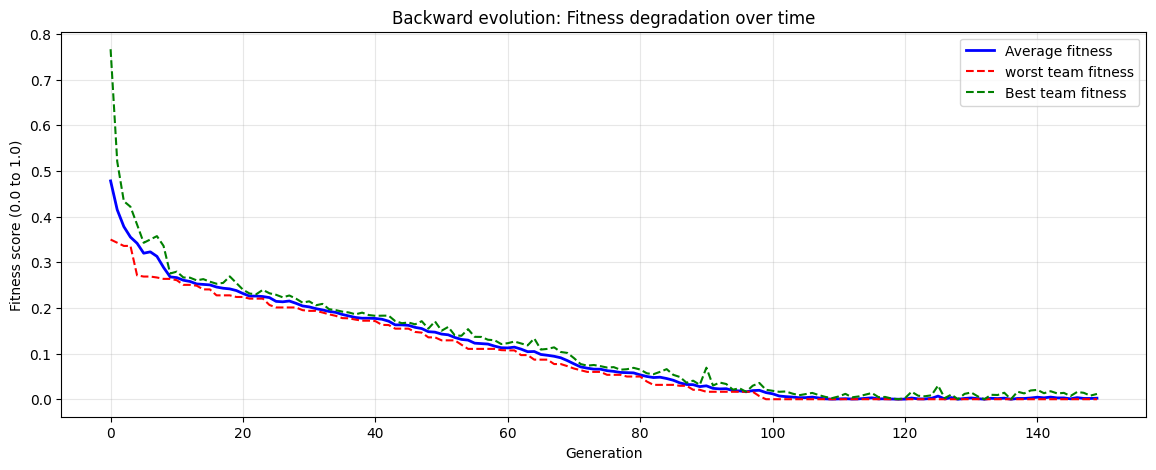

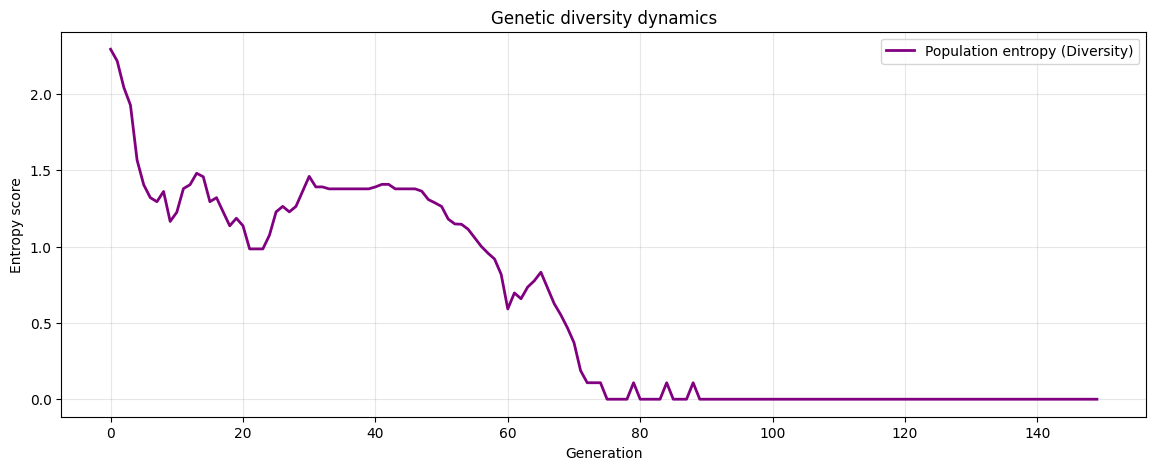

In [6]:
generations_count = 150
mean_fit, min_fit, max_fit, diversity = run_mayan_evolution(generations=generations_count)

plt.figure(figsize=(14,5))
plt.plot(mean_fit, label='Average fitness', color='blue', linewidth=2)
plt.plot(min_fit, label='worst team fitness', color='red', linestyle='--')
plt.plot(max_fit, label='Best team fitness', color='green', linestyle='--')
plt.title('Backward evolution: Fitness degradation over time')
plt.xlabel('Generation')
plt.ylabel('Fitness score (0.0 to 1.0)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.figure(figsize=(14,5))
plt.plot(diversity, label='Population entropy (Diversity)', color='purple', linewidth=2)
plt.title('Genetic diversity dynamics')
plt.xlabel('Generation')
plt.ylabel('Entropy score')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout
plt.show()